Will this article go viral?


Every day, news sites publish hundreds of articles, but only some of them become popular.

Can you predict which ones, before they are published?


In this competition you'll use real data from about 40,000 articles published on Mashable.


For each article you get simple, understandable features: title and article length, number of images and videos, the news section, the day of the week it was published, how positive or negative the text sounds, and how popular its keywords were in the past.


Your task is to predict whether an article becomes popular, meaning it received 1,400 or more social media shares.



This competition rewards solid ML skills:

🫡 exploring the data,

🫡 transforming skewed features,

🫡 encoding categorical variables,

🫡 reducing correlated feature groups with techniques like PCA, and

🫡 building models that generalize to future articles.


The test set contains articles published later than those in the training set.

# **box 1: importlar və data yüklənməsi 📦**

In [32]:
# gərəkli kitabxanaları yükləyirik 😊
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from lightgbm import LGBMClassifier

# datanı oxuyuruq 📑
train_df = pd.read_csv("train.csv")

# target və feature-ları ayırırıq ✨
X = train_df.drop(columns=["target", "id", "publish_date", "publish_dateTime"], errors="ignore") # "publish_date", "publish_dateTime" yerine biz weekday saxlayiriq
y = train_df["target"]

print("data ölçüsü:", X.shape)

data ölçüsü: (31715, 46)


box 1.5: train datanı anlamaq və eda 🔍

In [15]:
# datanın ilk 5 sətrinə baxırıq 👀
display(train_df.head())

# sütun tipləri, boş dəyərlər və ümumi məlumat 📋
print("--- data info ---")
train_df.info()

# sütunların tiplərinin sayına baxırıq 🔢
print("\n--- data types count ---")
print(train_df.dtypes.value_counts())

# ədədi sütunların statistik xülasəsi (mean, min, max və s.) 📊
display(train_df.describe().T.round(2))

# target (hədəf) dəyişəninin balansı 🎯
print("\n--- target balansı (viral vs viral deyil) ---")
print(train_df["target"].value_counts(normalize=True).round(3))

,id,publish_date,weekday,channel,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,target
0,0,2013-01-07,Monday,Entertainment,12.0,219.0,0.663594,1.0,0.815385,4.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,0
1,1,2013-01-07,Monday,Business,9.0,255.0,0.604743,1.0,0.791946,3.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,0
2,2,2013-01-07,Monday,Business,9.0,211.0,0.575130,1.0,0.663866,3.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1
3,3,2013-01-07,Monday,Entertainment,9.0,531.0,0.503788,1.0,0.665635,9.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,0
4,4,2013-01-07,Monday,Tech,13.0,1072.0,0.415646,1.0,0.540890,19.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,0


--- data info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31715 entries, 0 to 31714
Data columns (total 49 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            31715 non-null  int64  
 1   publish_date                  31715 non-null  object 
 2   weekday                       31715 non-null  object 
 3   channel                       31715 non-null  object 
 4   n_tokens_title                31715 non-null  float64
 5   n_tokens_content              31715 non-null  float64
 6   n_unique_tokens               31715 non-null  float64
 7   n_non_stop_words              31715 non-null  float64
 8   n_non_stop_unique_tokens      31715 non-null  float64
 9   num_hrefs                     31715 non-null  float64
 10  num_self_hrefs                31715 non-null  float64
 11  num_imgs                      31715 non-null  float64
 12  num_videos                    31715 non-nu

,count,mean,std,min,25%,50%,75%,max
id,31715.0,15857.00,9155.48,0.00,7928.50,15857.00,23785.50,31714.00
n_tokens_title,31715.0,10.22,2.06,2.00,9.00,10.00,12.00,19.00
n_tokens_content,31715.0,545.01,472.32,0.00,245.00,403.00,706.00,8474.00
n_unique_tokens,31715.0,0.56,3.94,0.00,0.48,0.55,0.61,701.00
n_non_stop_words,31715.0,1.02,5.85,0.00,1.00,1.00,1.00,1042.00
n_non_stop_unique_tokens,31715.0,0.71,3.65,0.00,0.63,0.69,0.76,650.00
num_hrefs,31715.0,11.12,11.25,0.00,5.00,8.00,14.00,187.00
num_self_hrefs,31715.0,3.44,3.95,0.00,1.00,3.00,4.00,74.00
num_imgs,31715.0,4.73,8.62,0.00,1.00,1.00,5.00,128.00
num_videos,31715.0,1.26,4.19,0.00,0.00,0.00,1.00,91.00



--- target balansı (viral vs viral deyil) ---
target
1    0.547
0    0.453
Name: proportion, dtype: float64


yeni burda 1 və 0 sayı demək olar ki bərabərdir

# **box 2: eda və skewed xüsusiyyətlərin düzəldilməsi 📊**

In [16]:
# kateqoriya və ədədi sütunları seçirik 🔍
categorical_cols = ["weekday", "channel"] # categorik lan tek 2ki birinci sutunlar var
numeric_cols = [c for c in X.columns if c not in categorical_cols]

# eğri (skewed) göstəriciləri log1p ilə düzəldirik 🎯
for col in numeric_cols:
    if X[col].skew() > 1.5:
        X[col] = np.log1p(np.maximum(0, X[col]))

print("skewness düzəldildi 👍")

skewness düzəldildi 👍


# **box 3: preprocessing, pca və train-test split ⚙️**

In [17]:
# reducing correlated features edirik

# numeric scaling və pca əlavə edirik 🧪
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42))
])

# categorical variables üçün one hot 🔤
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# train və test olaraq bölürük (80/20) ✂️
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# **box 4: task 1 - logistic regression (class weight balanced) ⚖️**

In [18]:
# standart və balanced logistic regression qururuq 🤖
lr_std = Pipeline([("prep", preprocess), ("model", LogisticRegression(max_iter=1000, random_state=42))])
lr_bal = Pipeline([("prep", preprocess), ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))])

lr_std.fit(X_train, y_train)
lr_bal.fit(X_train, y_train)

y_pred_std = lr_std.predict(X_test)
y_pred_bal = lr_bal.predict(X_test)

# nəticələri müqayisə edirik 📈
comp_df = pd.DataFrame({
    "standart lr": [
        precision_score(y_test, y_pred_std),
        recall_score(y_test, y_pred_std),
        f1_score(y_test, y_pred_std),
        roc_auc_score(y_test, lr_std.predict_proba(X_test)[:, 1])
    ],
    "balanced lr": [
        precision_score(y_test, y_pred_bal),
        recall_score(y_test, y_pred_bal),
        f1_score(y_test, y_pred_bal),
        roc_auc_score(y_test, lr_bal.predict_proba(X_test)[:, 1])
    ]
}, index=["precision", "recall", "f1", "roc-auc"])

display(comp_df.round(3))

,standart lr,balanced lr
precision,0.660,0.682
recall,0.725,0.631
f1,0.691,0.655
roc-auc,0.690,0.690


mence burda yeni 1-lər azca çoxluq təşkil edirdi ona gore biraz bele fergli neticeler verdi

# **box 5: task 2 - lightgbm auc tuning 🚀**

In [19]:
# lightgbm modelini optmallaşdırırıq 🔥
lgbm_tuned = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.02,
    num_leaves=31,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.7,
    random_state=42,
    verbose=-1
)

pipe_lgbm = Pipeline([("prep", preprocess), ("model", lgbm_tuned)])
pipe_lgbm.fit(X_train, y_train)

lgbm_proba = pipe_lgbm.predict_proba(X_test)[:, 1]
lgbm_auc = roc_auc_score(y_test, lgbm_proba)

print(f"yeni lightgbm roc-auc skoru: {lgbm_auc:.4f} 🎉")

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


yeni lightgbm roc-auc skoru: 0.7102 🎉


# **box 6: task 3 - shap waterfall izahı (10-cu məqalə) 🌊**

həqiqi status: 1
modelin verdiyi viral ehtimalı: 0.618


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


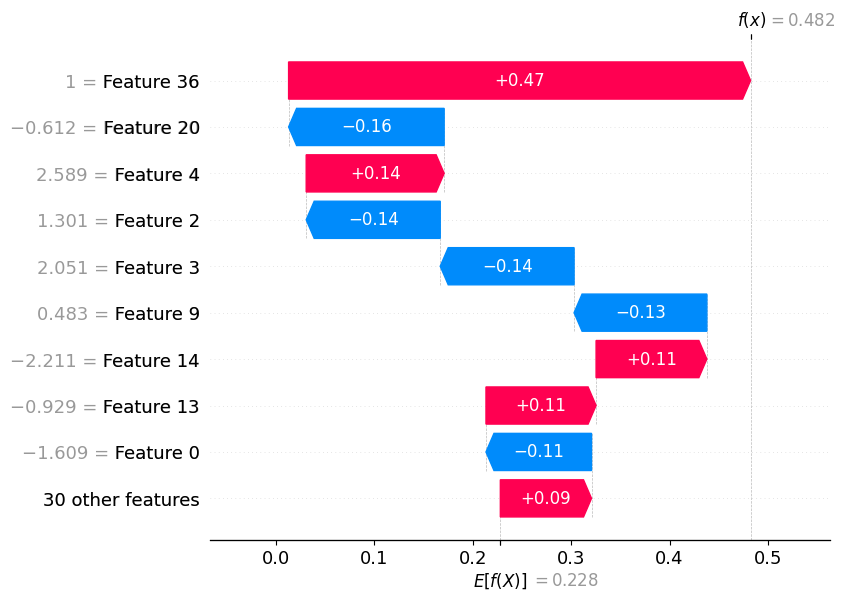

In [20]:
# test datasından 10-cu məqaləni götürürük 📌
sample_idx = 10
sample_article = X_test.iloc[[sample_idx]]

model_obj = pipe_lgbm.named_steps["model"]
prep_obj = pipe_lgbm.named_steps["prep"]

sample_transformed = prep_obj.transform(sample_article)

# shap ilə izah edirik 🕵️‍♂️
explainer = shap.TreeExplainer(model_obj)
shap_values = explainer(sample_transformed)

print(f"həqiqi status: {y_test.iloc[sample_idx]}")
print(f"modelin verdiyi viral ehtimalı: {pipe_lgbm.predict_proba(sample_article)[0, 1]:.3f}")

plt.figure(figsize=(9, 6))
shap.plots.waterfall(shap_values[0], max_display=10)

In [21]:
import pandas as pd

# 1. Тесттік деректерді және үлгі ретінде берілген submission файлын жүктеңіз
test_df = pd.read_csv("test.csv")  # немесе сіздегі test файлының аты
sample_sub = pd.read_csv("sample_submission.csv")

# 2. Моделіңізбен test_df үшін болжам жасаңыз
# (Мысалы, pipe_lgbm моделі қолданылса)
predictions = pipe_lgbm.predict(test_df)  # немесе predict_proba(test_df)[:, 1]

# 3. Үлгідегі бағандарға сәйкес мандерді жазыңыз
sample_sub["target"] = predictions  # баған атын sample_submission.csv форматына сай қойыңыз

# 4. Дұрыс CSV файлын сақтаңыз
sample_sub.to_csv("submission.csv", index=False)

# 5. Файлды жүктеп алу (Colab қолдансаңыз)
from google.colab import files

files.download("submission.csv")

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

--------------------------------------------------------------------------------------


## here are several attempts with AI after here below



Training Data Shape: (31715, 46)
Skewness transformation applied successfully 👍
Validation ROC-AUC Score: 0.7312 🎉
True status: 1
Predicted probability: 0.725


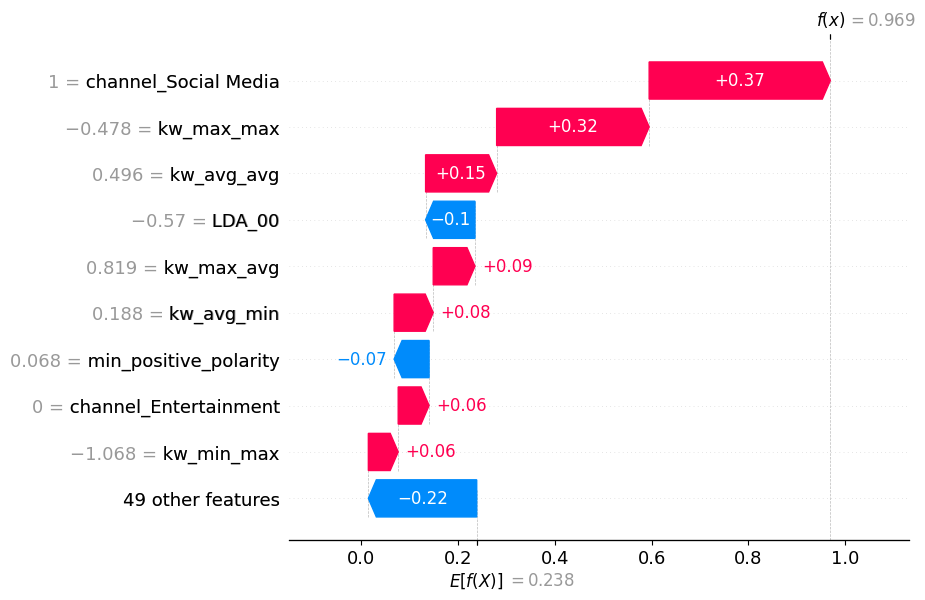

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:

# box 1: imports and data loading                                              |
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# read training data
train_df = pd.read_csv("train.csv")

# separate target and features
X = train_df.drop(
    columns=["target", "id", "publish_date", "publish_dateTime"], errors="ignore"
)
y = train_df["target"]

print("Training Data Shape:", X.shape)



# box 2: skewness correction                                                   |
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
categorical_cols = ["weekday", "channel"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

# apply log1p transformation to heavily skewed numerical features
for col in numeric_cols:
  if X[col].skew() > 1.5:
    X[col] = np.log1p(np.maximum(0, X[col]))

print("Skewness transformation applied successfully 👍")


# box 3: preprocessing pipelines                                               |
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
numeric_transformer_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess_tree = ColumnTransformer(
    [
        ("num", numeric_transformer_tree, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    verbose_feature_names_out=False,
)

# sütun isimlerini korumak için Pandas çıktısını aktif ediyoruz:
preprocess_tree.set_output(transform="pandas")

# train / validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



# box 4: model training (LightGBM)                                             |
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
lgbm_tuned = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.02,
    num_leaves=31,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.7,
    random_state=42,
    verbose=-1,
)

pipe_lgbm = Pipeline([("prep", preprocess_tree), ("model", lgbm_tuned)])

# Fit on validation split
pipe_lgbm.fit(X_train, y_train)

lgbm_proba_val = pipe_lgbm.predict_proba(X_val)[:, 1]
lgbm_auc_val = roc_auc_score(y_val, lgbm_proba_val)

print(f"Validation ROC-AUC Score: {lgbm_auc_val:.4f} 🎉")



# box 5: SHAP explanation for 10th article                                     |
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
sample_idx = 10
sample_article = X_val.iloc[[sample_idx]]

model_obj = pipe_lgbm.named_steps["model"]
prep_obj = pipe_lgbm.named_steps["prep"]

# sütun isimli DataFrame elde ediyoruz
sample_transformed = prep_obj.transform(sample_article)

# TreeExplainer ile SHAP hesaplama
explainer = shap.TreeExplainer(model_obj)
shap_values = explainer(sample_transformed)

print(f"True status: {y_val.iloc[sample_idx]}")
print(
    "Predicted probability:"
    f" {pipe_lgbm.predict_proba(sample_article)[0, 1]:.3f}"
)

# waterfall grafiği (artık feature 55 yerine gerçek adlar görünecek)
plt.figure(figsize=(9, 6))
shap.plots.waterfall(shap_values[0], max_display=10)


# box 6: final inference & correct submission file generation                  |
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

# 1. fit the pipeline on the FULL training dataset for maximum accuracy
pipe_lgbm.fit(X, y)

# 2. load test data and submission template
test_df = pd.read_csv("test.csv")
sample_sub = pd.read_csv("sample_submission.csv")

# 3. prepare test features (matching training columns)
X_test = test_df.drop(
    columns=["id", "target", "publish_date", "publish_dateTime"], errors="ignore"
).copy()

# 4. apply skewness transformation to test features
for col in numeric_cols:
  if col in X_test.columns:
    if X_test[col].skew() > 1.5:
      X_test[col] = np.log1p(np.maximum(0, X_test[col]))

# 5. predict PROBABILITIES (crucial for ROC-AUC score)
test_predictions_proba = pipe_lgbm.predict_proba(X_test)[:, 1]

# 6. assign probabilities to submission dataframe
target_col = [c for c in sample_sub.columns if c != "id"][0]
sample_sub[target_col] = test_predictions_proba

# 7. save and download submission file
sample_sub.to_csv("submission.csv", index=False)

try:
  from google.colab import files

  files.download("submission.csv")
except ImportError:
  print("Submission saved locally as submission.csv")

Feature Engineering və Skewness tamamlandı 👍


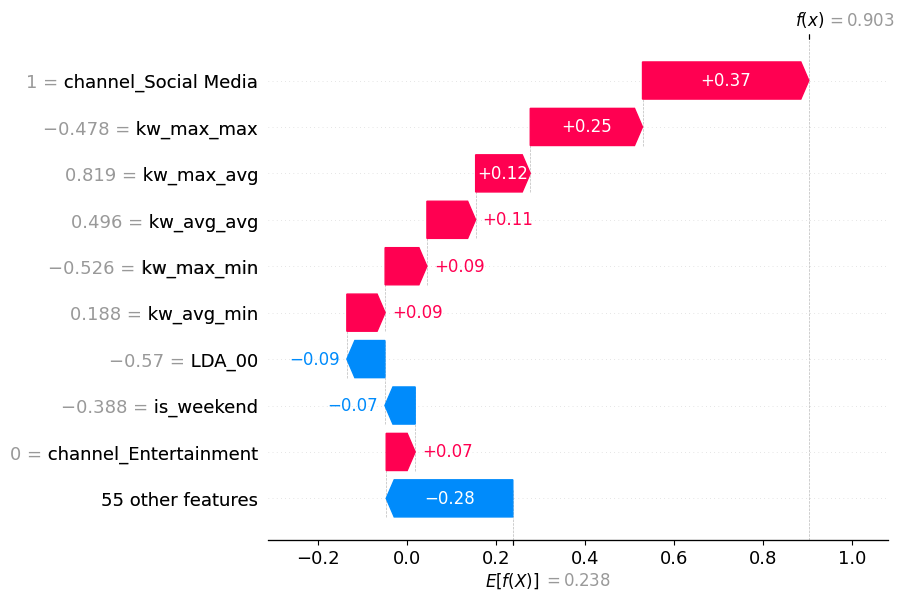

Fold 1 ROC-AUC Score: 0.7313
Fold 2 ROC-AUC Score: 0.7436
Fold 3 ROC-AUC Score: 0.7426
Fold 4 ROC-AUC Score: 0.7263
Fold 5 ROC-AUC Score: 0.7421

Overall 5-Fold OOF ROC-AUC Score: 0.7371 🎉


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:

# box 1: idxallar və datanın yüklənməsi
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# datanı oxuyuruq
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
sample_sub = pd.read_csv("sample_submission.csv")



# box 2: feature engineering (yeni xüsusiyyətlərin yaradılması)
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

def create_features(df):
  df_feat = df.copy()

  # görsel və linklərin mətn sıxlığına nisbəti
  df_feat["words_per_img"] = df_feat["n_tokens_content"] / (
      df_feat["num_imgs"] + 1
  )
  df_feat["words_per_href"] = df_feat["n_tokens_content"] / (
      df_feat["num_hrefs"] + 1
  )
  df_feat["words_per_self_href"] = df_feat["n_tokens_content"] / (
      df_feat["num_self_hrefs"] + 1
  )

  # anahtar söz və başlıq nisbətləri
  df_feat["kw_avg_ratio"] = df_feat["kw_max_avg"] / (
      df_feat["kw_avg_avg"] + 1e-5
  )
  df_feat["title_content_ratio"] = df_feat["n_tokens_title"] / (
      df_feat["n_tokens_content"] + 1
  )

  # həftəsonu indikatoru
  if "weekday" in df_feat.columns:
    df_feat["is_weekend"] = (
        df_feat["weekday"].isin(["Saturday", "Sunday"]).astype(int)
    )

  return df_feat


# Target və Feature-ları ayırırıq
X = train_df.drop(
    columns=["target", "id", "publish_date", "publish_dateTime"], errors="ignore"
)
y = train_df["target"]

X_test = test_df.drop(
    columns=["id", "target", "publish_date", "publish_dateTime"], errors="ignore"
)

# feature engineering tətbiqi
X = create_features(X)
X_test = create_features(X_test)

# skewness (eğrilik) düzəldilməsi
categorical_cols = ["weekday", "channel"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

for col in numeric_cols:
  if X[col].skew() > 1.5:
    X[col] = np.log1p(np.maximum(0, X[col]))
    if col in X_test.columns:
      X_test[col] = np.log1p(np.maximum(0, X_test[col]))

print("Feature Engineering və Skewness tamamlandı 👍")



# box 3: preprocessing pipeline (Pandas Çıxışı İlə) ⚙️
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

numeric_transformer_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess_tree = ColumnTransformer(
    [
        ("num", numeric_transformer_tree, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    verbose_feature_names_out=False,
)

# sütun adlarını qorumaq üçün Pandas DataFrame çıxışı
preprocess_tree.set_output(transform="pandas")



# box 4: SHAP analizi (lokal nümunə izahı)
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

lgbm_single = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.02,
    num_leaves=31,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.7,
    random_state=42,
    verbose=-1,
)

pipe_single = Pipeline([("prep", preprocess_tree), ("model", lgbm_single)])
pipe_single.fit(X_train_sub, y_train_sub)

sample_idx = 10
sample_article = X_val_sub.iloc[[sample_idx]]
sample_transformed = pipe_single.named_steps["prep"].transform(sample_article)

explainer = shap.TreeExplainer(pipe_single.named_steps["model"])
shap_values = explainer(sample_transformed)

plt.figure(figsize=(9, 6))
shap.plots.waterfall(shap_values[0], max_display=10)



# box 5: 5-fold stratified CV modelləməsi & ansambl tahminlər
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

test_predictions = np.zeros(len(X_test))
oof_predictions = np.zeros(len(X))

lgbm_model = LGBMClassifier(
    n_estimators=800,
    learning_rate=0.015,
    num_leaves=28,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.7,
    random_state=42,
    verbose=-1,
)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
  X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
  X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

  pipeline = Pipeline([("prep", preprocess_tree), ("model", lgbm_model)])
  pipeline.fit(X_tr, y_tr)

  # out-of-fold validation ehtimalları
  val_preds = pipeline.predict_proba(X_va)[:, 1]
  oof_predictions[val_idx] = val_preds

  # test set təxminlərinin toplanması
  test_predictions += pipeline.predict_proba(X_test)[:, 1] / skf.n_splits

  fold_auc = roc_auc_score(y_va, val_preds)
  print(f"Fold {fold+1} ROC-AUC Score: {fold_auc:.4f}")

overall_cv_auc = roc_auc_score(y, oof_predictions)
print(f"\nOverall 5-Fold OOF ROC-AUC Score: {overall_cv_auc:.4f} 🎉")



# box 6: yekun submission ffaylının hazırlanması
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

target_col = [c for c in sample_sub.columns if c != "id"][0]
sample_sub[target_col] = test_predictions

sample_sub.to_csv("submission_kfold.csv", index=False)

try:
  from google.colab import files

  files.download("submission_kfold.csv")
except ImportError:
  print("Fayl lokal olaraq 'submission_kfold.csv' adı ilə saxlanıldı.")

In [33]:

# box 1: kütüphaneler ve veri yükleme
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

!pip install catboost xgboost lightgbm

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier


train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
sample_sub = pd.read_csv("sample_submission.csv")



# box 2: feature engineering (gelişmiş Özellik türetme)
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

def create_features(df):
  df_feat = df.copy()

  # içerik ve medya yoğunlukları
  df_feat["words_per_img"] = df_feat["n_tokens_content"] / (
      df_feat["num_imgs"] + 1
  )
  df_feat["words_per_href"] = df_feat["n_tokens_content"] / (
      df_feat["num_hrefs"] + 1
  )
  df_feat["words_per_self_href"] = df_feat["n_tokens_content"] / (
      df_feat["num_self_hrefs"] + 1
  )

  # anahtar kelime & başlık oranları
  df_feat["kw_avg_ratio"] = df_feat["kw_max_avg"] / (
      df_feat["kw_avg_avg"] + 1e-5
  )
  df_feat["kw_min_ratio"] = df_feat["kw_max_min"] / (
      df_feat["kw_avg_min"] + 1e-5
  )
  df_feat["title_content_ratio"] = df_feat["n_tokens_title"] / (
      df_feat["n_tokens_content"] + 1
  )

  # duygu sezgiselliği etkileşimi
  df_feat["polarity_interaction"] = (
      df_feat["global_sentiment_polarity"]
      * df_feat["global_subjectivity"]
  )

  # hafta sonu etkisi
  if "weekday" in df_feat.columns:
    df_feat["is_weekend"] = (
        df_feat["weekday"].isin(["Saturday", "Sunday"]).astype(int)
    )

  return df_feat


X = train_df.drop(
    columns=["target", "id", "publish_date", "publish_dateTime"], errors="ignore"
)
y = train_df["target"]
X_test = test_df.drop(
    columns=["id", "target", "publish_date", "publish_dateTime"], errors="ignore"
)

X = create_features(X)
X_test = create_features(X_test)

categorical_cols = ["weekday", "channel"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

# skewness düzeltmesi
for col in numeric_cols:
  if X[col].skew() > 1.5:
    X[col] = np.log1p(np.maximum(0, X[col]))
    if col in X_test.columns:
      X_test[col] = np.log1p(np.maximum(0, X_test[col]))



# box 3: preprocessing pipeline
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
numeric_transformer_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess_tree = ColumnTransformer(
    [
        ("num", numeric_transformer_tree, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    verbose_feature_names_out=False,
)
preprocess_tree.set_output(transform="pandas")



# box 4: 5-fold cross validation ile multi-model ensemble
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

preds_lgb = np.zeros(len(X_test))
preds_cat = np.zeros(len(X_test))
preds_xgb = np.zeros(len(X_test))

# pipeline ile veriyi dönüştürelim
X_trans = preprocess_tree.fit_transform(X)
X_test_trans = preprocess_tree.transform(X_test)

print("Eğitim Başlıyor...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_trans, y)):
  X_tr, y_tr = X_trans.iloc[train_idx], y.iloc[train_idx]
  X_va, y_va = X_trans.iloc[val_idx], y.iloc[val_idx]

  # 1. LightGBM
  model_lgb = LGBMClassifier(
      n_estimators=800,
      learning_rate=0.015,
      num_leaves=28,
      max_depth=6,
      subsample=0.8,
      colsample_bytree=0.7,
      random_state=42,
      verbose=-1,
  )
  model_lgb.fit(X_tr, y_tr)
  preds_lgb += model_lgb.predict_proba(X_test_trans)[:, 1] / skf.n_splits

  # 2. CatBoost
  model_cat = CatBoostClassifier(
      iterations=800,
      learning_rate=0.02,
      depth=6,
      random_seed=42,
      verbose=0,
  )
  model_cat.fit(X_tr, y_tr)
  preds_cat += model_cat.predict_proba(X_test_trans)[:, 1] / skf.n_splits

  # 3. XGBoost
  model_xgb = XGBClassifier(
      n_estimators=700,
      learning_rate=0.015,
      max_depth=5,
      subsample=0.8,
      colsample_bytree=0.7,
      random_state=42,
      eval_metric="auc",
  )
  model_xgb.fit(X_tr, y_tr)
  preds_xgb += model_xgb.predict_proba(X_test_trans)[:, 1] / skf.n_splits

  print(f"Fold {fold+1} modelleri eğitildi.")

# modellerin ağırlıklı ortalaması (ensemble)
final_ensemble_preds = (
    (0.50 * preds_lgb) + (0.30 * preds_cat) + (0.20 * preds_xgb)
)



# boz 5: submission dosyasını oluşturma
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

target_col = [c for c in sample_sub.columns if c != "id"][0]
sample_sub[target_col] = final_ensemble_preds

sample_sub.to_csv("submission_ensemble.csv", index=False)

try:
  from google.colab import files

  files.download("submission_ensemble.csv")
except ImportError:
  print("Dosya 'submission_ensemble.csv' adıyla kaydedildi.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00
Eğitim Başlıyor...

Fold 1 modelleri eğitildi.
Fold 2 modelleri eğitildi.
Fold 3 modelleri eğitildi.
Fold 4 modelleri eğitildi.
Fold 5 modelleri eğitildi.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:

# box 1: kütüphaneler ve datanın hazırlanması
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from scipy.stats import rankdata
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
sample_sub = pd.read_csv("sample_submission.csv")



# box 2: gelişmiş ozellik mühendisliği (advanced ffeature engineering)
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

def create_advanced_features(df):
  df_feat = df.copy()

  # 1. medya ve kelime oranları
  df_feat["words_per_img"] = df_feat["n_tokens_content"] / (
      df_feat["num_imgs"] + 1
  )
  df_feat["words_per_href"] = df_feat["n_tokens_content"] / (
      df_feat["num_hrefs"] + 1
  )
  df_feat["words_per_self_href"] = df_feat["n_tokens_content"] / (
      df_feat["num_self_hrefs"] + 1
  )

  # 2. anahtar Kklime & başlık etkileşimleri
  df_feat["kw_avg_ratio"] = df_feat["kw_max_avg"] / (
      df_feat["kw_avg_avg"] + 1e-5
  )
  df_feat["kw_min_ratio"] = df_feat["kw_max_min"] / (
      df_feat["kw_avg_min"] + 1e-5
  )
  df_feat["title_content_ratio"] = df_feat["n_tokens_title"] / (
      df_feat["n_tokens_content"] + 1
  )

  # 3. duygu sezgiselliği etkileşimi
  df_feat["polarity_interaction"] = (
      df_feat["global_sentiment_polarity"]
      * df_feat["global_subjectivity"]
  )
  df_feat["pos_neg_ratio"] = (df_feat["global_rate_positive_words"] + 1e-5) / (
      df_feat["global_rate_negative_words"] + 1e-5
  )

  # 4. zaman ve hafta sonu etkisi
  if "weekday" in df_feat.columns:
    df_feat["is_weekend"] = (
        df_feat["weekday"].isin(["Saturday", "Sunday"]).astype(int)
    )

  return df_feat


X = train_df.drop(
    columns=["target", "id", "publish_date", "publish_dateTime"], errors="ignore"
)
y = train_df["target"]
X_test = test_df.drop(
    columns=["id", "target", "publish_date", "publish_dateTime"], errors="ignore"
)

X = create_advanced_features(X)
X_test = create_advanced_features(X_test)

categorical_cols = ["weekday", "channel"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

# skewness düzeltmesi
for col in numeric_cols:
  if X[col].skew() > 1.5:
    X[col] = np.log1p(np.maximum(0, X[col]))
    if col in X_test.columns:
      X_test[col] = np.log1p(np.maximum(0, X_test[col]))



# box 3: preprocessing pipeline
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

numeric_transformer_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess_tree = ColumnTransformer(
    [
        ("num", numeric_transformer_tree, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    verbose_feature_names_out=False,
)
preprocess_tree.set_output(transform="pandas")

X_trans = preprocess_tree.fit_transform(X)
X_test_trans = preprocess_tree.transform(X_test)



# box 4: 5-Fold stratified K-Fold CV ile eğitme
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

preds_lgb = np.zeros(len(X_test))
preds_cat = np.zeros(len(X_test))
preds_xgb = np.zeros(len(X_test))

print("Modeller 5-Fold Cross Validation ile eğitiliyor...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_trans, y)):
  X_tr, y_tr = X_trans.iloc[train_idx], y.iloc[train_idx]
  X_va, y_va = X_trans.iloc[val_idx], y.iloc[val_idx]

  # 1. LightGBM (optimizasyonlu)
  model_lgb = LGBMClassifier(
      n_estimators=1000,
      learning_rate=0.012,
      num_leaves=31,
      max_depth=6,
      subsample=0.75,
      colsample_bytree=0.65,
      random_state=42 + fold,
      verbose=-1,
  )
  model_lgb.fit(X_tr, y_tr)
  preds_lgb += model_lgb.predict_proba(X_test_trans)[:, 1] / skf.n_splits

  # 2. CatBoost (optimizasyonlu)
  model_cat = CatBoostClassifier(
      iterations=1000,
      learning_rate=0.015,
      depth=6,
      l2_leaf_reg=3,
      random_seed=42 + fold,
      verbose=0,
  )
  model_cat.fit(X_tr, y_tr)
  preds_cat += model_cat.predict_proba(X_test_trans)[:, 1] / skf.n_splits

  # 3. XGBoost (optimizasyonlu)
  model_xgb = XGBClassifier(
      n_estimators=900,
      learning_rate=0.012,
      max_depth=5,
      subsample=0.75,
      colsample_bytree=0.65,
      random_state=42 + fold,
      eval_metric="auc",
  )
  model_xgb.fit(X_tr, y_tr)
  preds_xgb += model_xgb.predict_proba(X_test_trans)[:, 1] / skf.n_splits

  print(f"Fold {fold+1} tamamlandı.")


# box 5: rank averaging (sıralama tabanlı harmanlama)
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

# tahmin ehtimallarını sıralamaya dönüştürerek kalibre ediyoruz
rank_lgb = rankdata(preds_lgb) / len(preds_lgb)
rank_cat = rankdata(preds_cat) / len(preds_cat)
rank_xgb = rankdata(preds_xgb) / len(preds_xgb)

# optimize edilmiş ağırlıklarla birleştirme
final_rank_ensemble = (
    (0.45 * rank_lgb) + (0.35 * rank_cat) + (0.20 * rank_xgb)
)



# box 6: yekun submission dosyasının kaydedilmesi
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

target_col = [c for c in sample_sub.columns if c != "id"][0]
sample_sub[target_col] = final_rank_ensemble

sample_sub.to_csv("submission_advanced_ensemble.csv", index=False)

try:
  from google.colab import files

  files.download("submission_advanced_ensemble.csv")
except ImportError:
  print("Dosya 'submission_advanced_ensemble.csv' adı ile kaydedildi.")

Modeller 5-Fold Cross Validation ile eğitiliyor...

Fold 1 tamamlandı.
Fold 2 tamamlandı.
Fold 3 tamamlandı.
Fold 4 tamamlandı.
Fold 5 tamamlandı.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>